<a href="https://colab.research.google.com/github/crowell97/ES5201/blob/main/ES5201_Lecture6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The 1-D Wave Equation — A Companion Notebook

**EARTH 5201 — Introduction to Seismology**

**The Ohio State University**

**Companion notebook to Lecture 6 — The 1-D Wave Equation**

This notebook turns every derivation from lecture into runnable code:

1. **Numerically solving the wave equation** — a finite-difference simulation of a pulse crossing an impedance boundary (this is exactly what generated the simulation figure shown in lecture).
2. **Harmonic waves** — building a traveling wave and visualizing period/wavelength.
3. **Reflection & transmission coefficients** — a reusable function, checked against the lecture's worked example.
4. **Energy** — verifying that energy (not amplitude) is what's actually conserved across a boundary.
5. **Normal modes** — mode shapes, eigenfrequencies, and reconstructing a localized pulse from a sum of 40 global standing waves.
6. **A bonus**: a simple synthetic illustration of how this exact same machinery — scaled up to 3-D — produces the Earth's free-oscillation spectrum.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pylab as plt

plt.rcParams["figure.figsize"] = (9, 4)

## Part 1 — Solving the 1-D Wave Equation Numerically

We'll simulate a pulse on a string with **fixed ends**, tension constant throughout, but a **density jump** partway along — creating a genuine impedance contrast, exactly like the two-string reflection/transmission problem from lecture.

The finite-difference (leapfrog) scheme discretizes $c^2 \partial^2u/\partial x^2 = \partial^2u/\partial t^2$ directly:

$$u_i^{n+1} = 2u_i^n - u_i^{n-1} + \Delta t^2\, \frac{\tau}{\rho_i}\,\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}$$

In [2]:
L = 20.0
nx = 401
dx = L / (nx - 1)
x = np.linspace(0, L, nx)

rho = np.where(x < 10, 3.0, 6.0)   # density jump at x=10 (matches lecture example)
tau = 1.0                          # tension -- SAME on both sides
c_local = np.sqrt(tau / rho)       # wave speed genuinely differs each side

print(f"Speed on the left:  {c_local[0]:.3f}")
print(f"Speed on the right: {c_local[-1]:.3f}")

Speed on the left:  0.577
Speed on the right: 0.408


In [3]:
# CFL stability condition: dt must be small enough relative to dx and the fastest local speed
dt = 0.3 * dx / c_local.max()
nt = 420

# Launch a RIGHT-MOVING-ONLY pulse (matches the "incident wave" framing from lecture)
pulse_width = 0.6
x_start = 6.5

def pulse(xc):
    return np.exp(-((x - xc) ** 2) / (2 * pulse_width ** 2))

c1 = c_local[0]
u_curr = pulse(x_start)
u_prev = pulse(x_start - c1 * dt)   # where the pulse was one step earlier
u_curr[0] = u_curr[-1] = u_prev[0] = u_prev[-1] = 0.0

In [4]:
snapshots, snap_times = [u_curr.copy()], [0]

for n in range(1, nt):
    u_next = np.zeros(nx)
    lap = (tau / rho[1:-1]) * (u_curr[2:] - 2 * u_curr[1:-1] + u_curr[:-2]) / dx ** 2
    u_next[1:-1] = 2 * u_curr[1:-1] - u_prev[1:-1] + dt ** 2 * lap
    u_next[0] = u_next[-1] = 0.0   # fixed ends
    u_prev, u_curr = u_curr, u_next
    if n % 30 == 0:
        snapshots.append(u_curr.copy())
        snap_times.append(n)

print("Number of snapshots:", len(snapshots))
print("Max |u| (should stay \u2248 1, confirming no numerical blow-up):",
      max(np.max(np.abs(s)) for s in snapshots))

Number of snapshots: 14
Max |u| (should stay ≈ 1, confirming no numerical blow-up): 1.0001860415781136


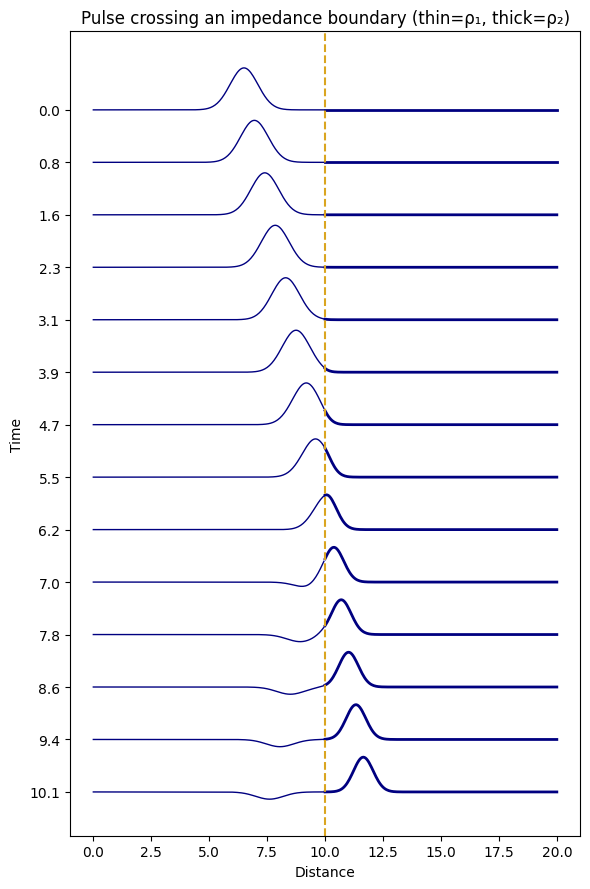

In [5]:
fig, ax = plt.subplots(figsize=(6, 9))
for i, snap in enumerate(snapshots):
    y_off = -i * 1.0
    left, right = x < 10, x >= 10
    ax.plot(x[left], snap[left] * 0.8 + y_off, color="navy", linewidth=1)
    ax.plot(x[right], snap[right] * 0.8 + y_off, color="navy", linewidth=2)
ax.axvline(10, color="goldenrod", linestyle="--")
ax.set_yticks(-np.arange(len(snapshots)))
ax.set_yticklabels([f"{t*dt:.1f}" for t in snap_times])
ax.set_xlabel("Distance"); ax.set_ylabel("Time")
ax.set_title("Pulse crossing an impedance boundary (thin=\u03c1\u2081, thick=\u03c1\u2082)")
plt.tight_layout()
plt.show()

## Part 2 — Harmonic Waves

A quick visualization of $u(x,t) = A\cos(\omega t - kx)$, sliced at fixed $x$ (a seismogram) and at fixed $t$ (a snapshot) — reproducing the period/wavelength figure from lecture.

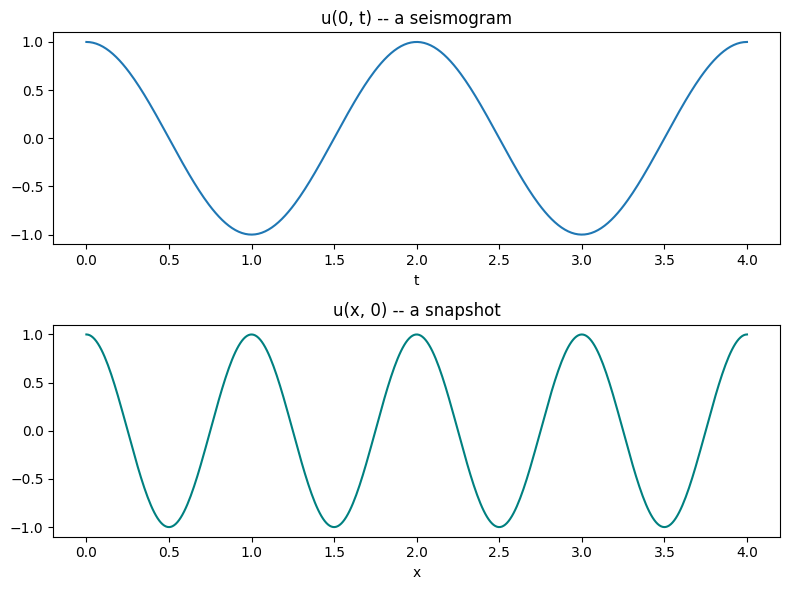

Period T = 2.00, Wavelength λ = 1.00, c = ω/k = 0.50


In [6]:
A, omega, k = 1.0, np.pi, 2 * np.pi   # matches the lecture's example (T=2, lambda=1)

t = np.linspace(0, 4, 400)
x_fixed_slice = np.cos(omega * t)   # u(0, t)

xs = np.linspace(0, 4, 400)
t_fixed_slice = np.cos(k * xs)      # u(x, 0)

fig, axes = plt.subplots(2, 1, figsize=(8, 6))
axes[0].plot(t, x_fixed_slice); axes[0].set_title("u(0, t) -- a seismogram"); axes[0].set_xlabel("t")
axes[1].plot(xs, t_fixed_slice, color="teal"); axes[1].set_title("u(x, 0) -- a snapshot"); axes[1].set_xlabel("x")
plt.tight_layout()
plt.show()

T = 2 * np.pi / omega
wavelength = 2 * np.pi / k
print(f"Period T = {T:.2f}, Wavelength \u03bb = {wavelength:.2f}, c = \u03c9/k = {omega/k:.2f}")

## Part 3 — Reflection & Transmission Coefficients

A direct implementation of $R_{12}$ and $T_{12}$, checked against the lecture's worked example (impedance 3 on the left, 6 on the right).

In [7]:
def reflection_transmission(rho1, c1, rho2, c2):
    """Reflection and transmission coefficients for a 1-D impedance boundary."""
    Z1, Z2 = rho1 * c1, rho2 * c2
    R12 = (Z1 - Z2) / (Z1 + Z2)
    T12 = 2 * Z1 / (Z1 + Z2)
    return R12, T12

R12, T12 = reflection_transmission(rho1=3, c1=1, rho2=6, c2=1)
print(f"R12 = {R12:.3f}   T12 = {T12:.3f}")
print("Check: 1 + R12 =", 1 + R12, " should equal T12 =", T12)

R12 = -0.333   T12 = 0.667
Check: 1 + R12 = 0.6666666666666667  should equal T12 = 0.6666666666666666


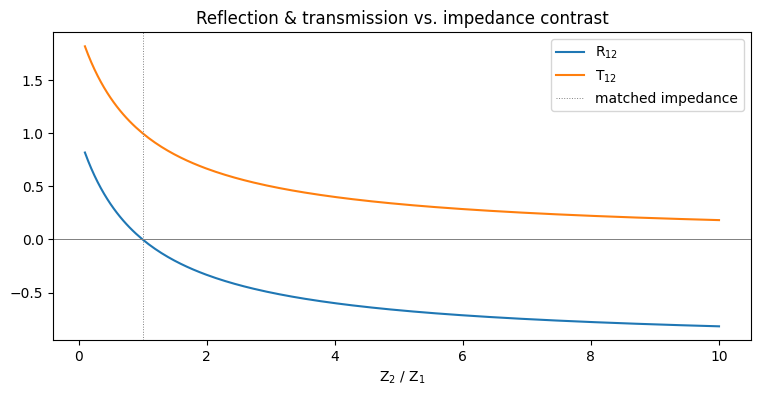

In [8]:
# Explore how R12 varies with the impedance ratio
Z_ratio = np.linspace(0.1, 10, 200)   # Z2 / Z1
R = (1 - Z_ratio) / (1 + Z_ratio)
T = 2 / (1 + Z_ratio)

plt.plot(Z_ratio, R, label="R$_{12}$")
plt.plot(Z_ratio, T, label="T$_{12}$")
plt.axhline(0, color="gray", linewidth=0.7)
plt.axvline(1, color="gray", linestyle=":", linewidth=0.7, label="matched impedance")
plt.xlabel("Z$_2$ / Z$_1$"); plt.legend()
plt.title("Reflection & transmission vs. impedance contrast")
plt.show()

Notice $T_{12}$ can exceed 1 once $Z_2/Z_1 < 1$ — this is exactly the "amplitude isn't everything" case flagged in lecture, resolved next by looking at energy instead.

## Part 4 — Energy: What's Actually Conserved

Average energy flux for a harmonic wave is $\dot E = \tfrac12 A^2\omega^2\rho c$. Let's verify that $E_{\text{incident}} = E_{\text{reflected}} + E_{\text{transmitted}}$ even in a case where $T_{12} > 1$.

In [9]:
def wave_energy_flux(A, omega, rho, c):
    return 0.5 * A**2 * omega**2 * rho * c

rho1, c1, rho2, c2 = 6.0, 1.0, 1.0, 1.0   # Z2 < Z1, so T12 will exceed 1
R12, T12 = reflection_transmission(rho1, c1, rho2, c2)
print(f"R12={R12:.3f}  T12={T12:.3f}  (T12 > 1: {T12 > 1})")

A, omega = 1.0, 2 * np.pi
E_incident = wave_energy_flux(A, omega, rho1, c1)
E_reflected = wave_energy_flux(abs(R12) * A, omega, rho1, c1)
E_transmitted = wave_energy_flux(T12 * A, omega, rho2, c2)

print(f"\nIncident energy flux:              {E_incident:.4f}")
print(f"Reflected + transmitted energy flux: {E_reflected + E_transmitted:.4f}")
assert np.isclose(E_incident, E_reflected + E_transmitted)
print("\nEnergy is conserved, even though T12 > 1 in amplitude.")

R12=0.714  T12=1.714  (T12 > 1: True)

Incident energy flux:              118.4353
Reflected + transmitted energy flux: 118.4353

Energy is conserved, even though T12 > 1 in amplitude.


## Part 5 — Normal Modes

### 5.1 Mode shapes and eigenfrequencies

n=1:  omega_n = 0.1571 rad/s,  period = 40.00 s
n=2:  omega_n = 0.3142 rad/s,  period = 20.00 s
n=3:  omega_n = 0.4712 rad/s,  period = 13.33 s
n=4:  omega_n = 0.6283 rad/s,  period = 10.00 s


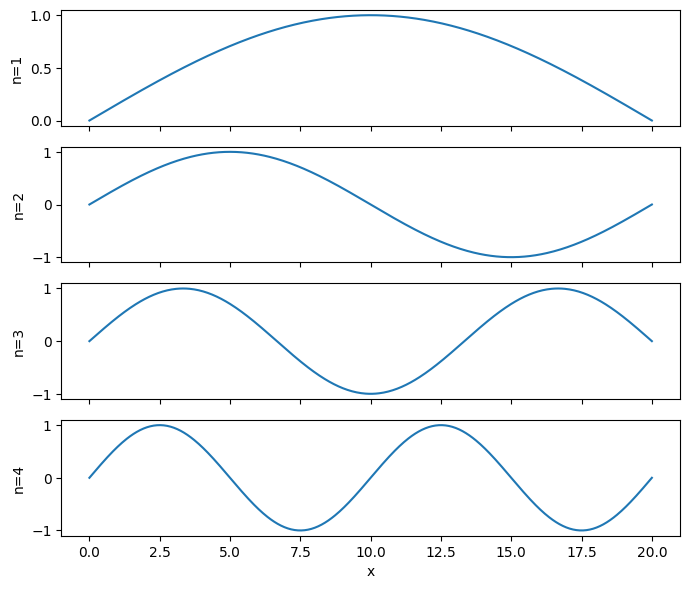

In [10]:
L, c = 20.0, 1.0
x = np.linspace(0, L, 500)

fig, axes = plt.subplots(4, 1, figsize=(7, 6), sharex=True)
for n, ax in zip([1, 2, 3, 4], axes):
    Un = np.sin(n * np.pi * x / L)
    wn = n * np.pi * c / L
    ax.plot(x, Un)
    ax.set_ylabel(f"n={n}")
    print(f"n={n}:  omega_n = {wn:.4f} rad/s,  period = {2*np.pi/wn:.2f} s")
axes[-1].set_xlabel("x")
plt.tight_layout()
plt.show()

### 5.2 Reconstructing a localized pulse from 40 global modes

Even though every individual mode spans the *entire* string, a weighted sum of just 40 of them reconstructs a pair of localized pulses, equally spaced from the source position — exactly the figure shown in lecture.

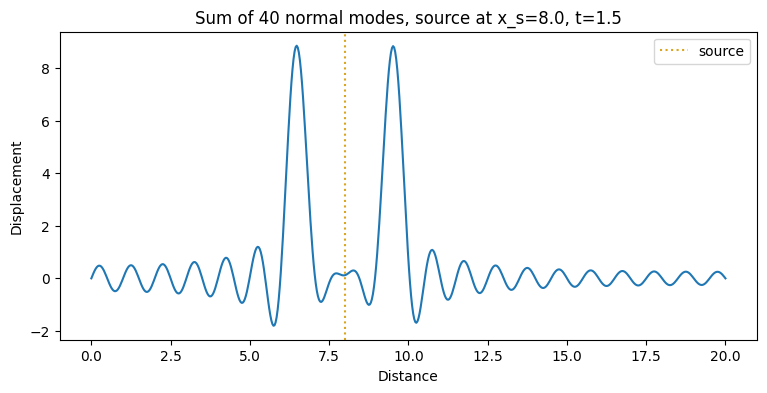

In [11]:
L, c, xs, t_snap = 20.0, 1.0, 8.0, 1.5   # matches lecture's example exactly
x = np.linspace(0, L, 600)

def mode_sum(x, xs, t, n_modes=40, tau_src=0.2, L=20.0, c=1.0):
    u = np.zeros_like(x)
    for n in range(1, n_modes + 1):
        wn = n * np.pi * c / L
        An = np.sin(n * np.pi * xs / L) * np.exp(-(wn * tau_src) ** 2 / 4)   # source weighting F(wn)
        Un = np.sin(n * np.pi * x / L)                                       # eigenfunction
        u += An * Un * np.cos(wn * t)
    return u

u_sum = mode_sum(x, xs, t_snap)

plt.plot(x, u_sum)
plt.axvline(xs, color="goldenrod", linestyle=":", label="source")
plt.xlabel("Distance"); plt.ylabel("Displacement")
plt.title(f"Sum of 40 normal modes, source at x_s={xs}, t={t_snap}")
plt.legend()
plt.show()

In [12]:
# Confirm the two peaks are (nearly) symmetric about the source location
peak_idx = np.argsort(np.abs(u_sum))[-20:]   # near the largest-amplitude points
left_peaks = x[peak_idx][x[peak_idx] < xs]
right_peaks = x[peak_idx][x[peak_idx] > xs]
if len(left_peaks) and len(right_peaks):
    print(f"Closest peak left of source:  x = {left_peaks.max():.2f}  (distance {xs - left_peaks.max():.2f})")
    print(f"Closest peak right of source: x = {right_peaks.min():.2f}  (distance {right_peaks.min() - xs:.2f})")

Closest peak left of source:  x = 6.61  (distance 1.39)
Closest peak right of source: x = 9.38  (distance 1.38)


### 5.3 How many modes do we need?

The more modes included in the sum, the sharper the reconstructed pulses become, and the smaller the residual ripples from truncating an in-principle-infinite series.

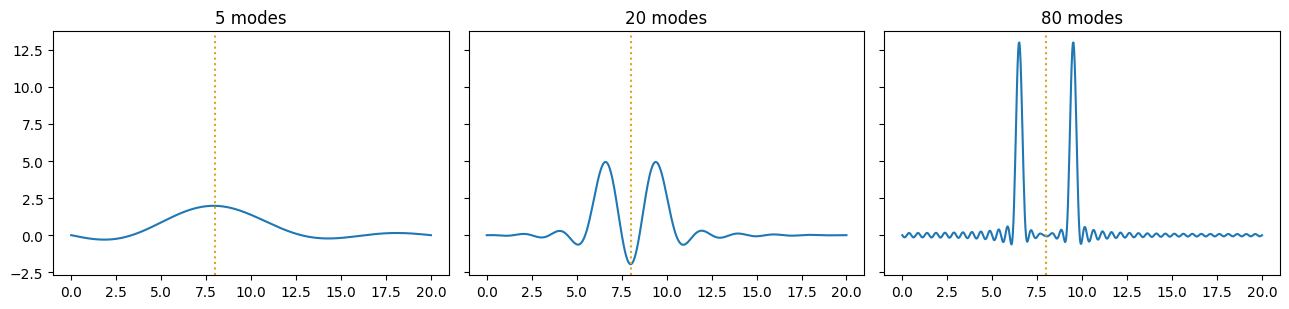

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, n_modes in zip(axes, [5, 20, 80]):
    u = mode_sum(x, xs, t_snap, n_modes=n_modes)
    ax.plot(x, u)
    ax.set_title(f"{n_modes} modes")
    ax.axvline(xs, color="goldenrod", linestyle=":")
plt.tight_layout()
plt.show()

## Part 6 — Bonus: From a String to the Earth

Lecture 6 ends by pointing out that the Earth's free oscillations (normal modes) are governed by the *same* eigenvalue problem as our string — just in 3-D, with spheroidal ($_nS_l$) and toroidal ($_nT_l$) modes instead of a single family of $\sin(n\pi x/L)$ shapes.

We can't derive the Earth's real normal-mode frequencies here (that requires solving the full 3-D elastic-wave eigenvalue problem for a radially varying sphere), but we can build a simple **schematic** amplitude spectrum showing what a normal-mode recording looks like conceptually: a series of sharp spectral peaks at the Earth's (real, published) longest-period fundamental mode frequencies, exactly as would be measured after a great earthquake.

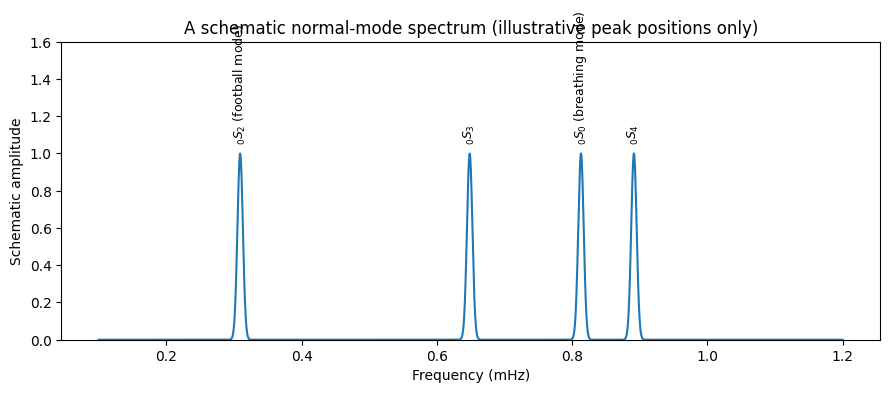

In [14]:
# Schematic only: approximate periods (minutes) of a few well-known
# fundamental spheroidal modes, for illustration (see IRIS/PREM mode catalogs
# for precise, authoritative eigenfrequencies).
named_modes = {
    "$_0S_2$ (football mode)": 53.9,
    "$_0S_3$": 25.7,
    "$_0S_4$": 18.7,
    "$_0S_0$ (breathing mode)": 20.5,
}

freq_mHz = {name: 1000 / (period * 60) for name, period in named_modes.items()}

f = np.linspace(0.1, 1.2, 3000)   # mHz
spectrum = np.zeros_like(f)
for name, f0 in freq_mHz.items():
    spectrum += np.exp(-((f - f0) ** 2) / (2 * 0.004 ** 2))   # narrow synthetic peak

plt.plot(f, spectrum)
for name, f0 in freq_mHz.items():
    plt.annotate(name, xy=(f0, 1.05), ha="center", fontsize=9, rotation=90, va="bottom")
plt.xlabel("Frequency (mHz)")
plt.ylabel("Schematic amplitude")
plt.title("A schematic normal-mode spectrum (illustrative peak positions only)")
plt.ylim(0, 1.6)
plt.tight_layout()
plt.show()

## Summary & Further Resources

- **Wave equation** — `c**2 * d2u/dx2 = d2u/dt2`; solved numerically here with a simple leapfrog finite-difference scheme.
- **Reflection/transmission** — governed entirely by impedance ratio $Z=\rho c$; amplitude coefficients can exceed 1, but energy flux never does.
- **Normal modes** — any wave on a finite string is a weighted sum of discrete standing-wave eigenfunctions; the same idea, generalized to 3-D, gives the Earth's free oscillations.

**Links:**
- IRIS/EarthScope normal-mode and free-oscillation resources: https://www.iris.edu/
- Dziewonski, A. M., and D. L. Anderson (1981), *Preliminary Reference Earth Model*, Phys. Earth Planet. Inter. — the classic reference-model paper built substantially from normal-mode data.
- Dahlen, F. A., and J. Tromp, *Theoretical Global Seismology* — the standard graduate reference for normal-mode theory.